# Read UDP Packets

Valid data: packet 36722!
RSP Version: 3
RSP ID: 0 | Unused 1: 0 | RSP Error: 0 | Clock Bit: 1
Bit Mode: 0 | Unused 2: 0
Config: 170
Station ID: 57370
Number of beamlets: 61
Number of time samples: 16
Timestamp: 311805799
Sequence: 1057357824
[0 1 2 3 4 5 6 7 8 9]


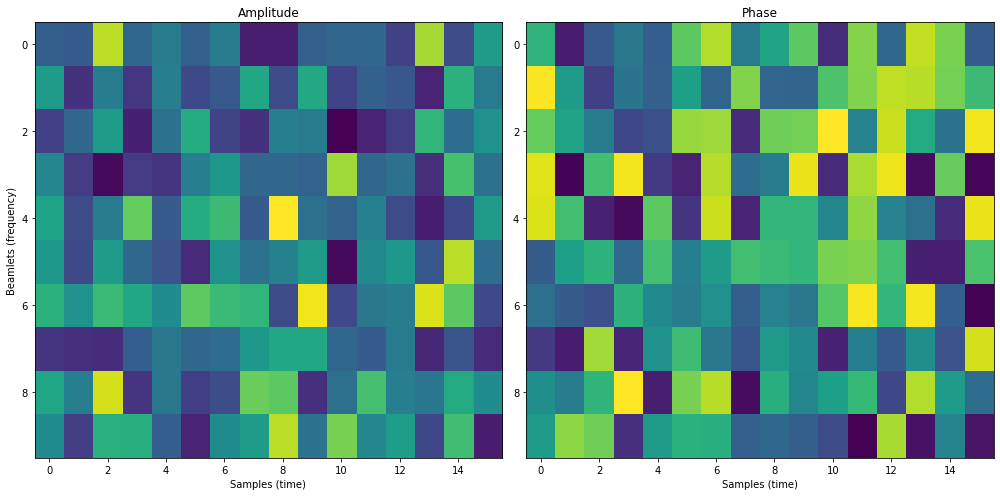

In [12]:
import struct
import numpy as np
import matplotlib.pyplot as plt

filename = r"C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\udp_16140.radio.2025-03-05T00_04_31.001"
valid_packet_data = None
pack_counter = 0
valid_count = 0

with open(filename, "rb") as f:
    while True:
        packet = f.read(7824)
        if len(packet) < 7824: 
            break # End of file
            
        pack_counter += 1
        
        # 16-byte header
        header = packet[:16]
        rsp_version = header[0]
        
        byte1 = format(header[1], '08b')
        clock_bit = int(byte1[0], 2)       # Bit 7 (1 caracter a la izquierda)
        rsp_error = int(byte1[1], 2)       # Bit 6 
        unused_1 = int(byte1[2], 2)        # Bit 5
        rsp_id = int(byte1[-5:], 2)        # Bits 0-4 (5 caracteres a la derecha)
        
        byte2 = format(header[2], '08b')
        unused_2 = int(byte2[:6], 2)       # Bits 2-7 (6 caracteres a la izquierda)
        bit_mode = int(byte2[-2:], 2)      # Bits 0-1 (2 caracteres a la derecha)
        
        config = header[3]
        beamlets = header[6]
        time_samples = header[7]
        
        station_id = struct.unpack('>H', header[4:6])[0] # 2 bytes (H)
        timestamp = struct.unpack('>I', header[8:12])[0] # 4 bytes (I)
        sequence = struct.unpack('>I', header[12:16])[0] # 4 bytes (I)

        data = packet[16:]
        
        # Read as 16-bit integers (combines every 2 bytes into 1 number)
        antenna_data = np.frombuffer(data, dtype=np.int16)
        
        # If there's any non-zero data, we process it and stop.
        if np.any(antenna_data):
            valid_count += 1
            if valid_count > 100: #changing this number i change the packet i see
                # Reshape: 61 beamlets x 16 samples x 4 parts (X_real, X_imag, Y_real, Y_imag)
                valid_packet_data = antenna_data.reshape((61, 16, 4))
                print(f"Valid data: packet {pack_counter}!")
                break

if valid_packet_data is not None:
    print(f"RSP Version: {rsp_version}")
    print(f"RSP ID: {rsp_id} | Unused 1: {unused_1} | RSP Error: {rsp_error} | Clock Bit: {clock_bit}")
    print(f"Bit Mode: {bit_mode} | Unused 2: {unused_2}")
    print(f"Config: {config}")
    print(f"Station ID: {station_id}")
    print(f"Number of beamlets: {beamlets}")
    print(f"Number of time samples: {time_samples}")
    print(f"Timestamp: {timestamp}")
    print(f"Sequence: {sequence}")
    
    # Extract the Real and Imaginary parts for Antenna X (indices 0 and 1)
    # Convert to float to prevent overflow during mathematical operations
    real_part = valid_packet_data[:, :, 0].astype(float)
    imag_part = valid_packet_data[:, :, 1].astype(float)

    # Calculate Amplitude and Phase
    amplitude = np.sqrt(real_part**2 + imag_part**2)
    phase = np.arctan2(imag_part, real_part)
    
    # AUTOMATIC DETECTION OF ZERO PACKET
    beamlet_max = np.max(amplitude, axis=1)
    beamlet_w_data = np.where(beamlet_max > 0)[0]
    print(beamlet_w_data)
    
    if len(beamlet_w_data) > 0:
        ylim = beamlet_w_data[-1]
    else:
        ylim = 61
    
    amplitude = amplitude[beamlet_w_data, :]
    phase = phase[beamlet_w_data, :]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    ax1.imshow(amplitude, aspect='auto', interpolation='none', cmap='viridis')
    ax1.set_title("Amplitude")
    ax1.set_xlabel("Samples (time)")
    ax1.set_ylabel("Beamlets (frequency)")

    ax2.imshow(phase, aspect='auto', interpolation='none', cmap='viridis')
    ax2.set_title("Phase")
    ax2.set_xlabel("Samples (time)")


    plt.tight_layout()
    plt.show()

# Read 1 full file

0.5 seconds (6103 packets) of data processed
1.0 seconds (12206 packets) of data processed
1.5 seconds (18309 packets) of data processed
2.0 seconds (24412 packets) of data processed
2.5 seconds (30515 packets) of data processed
3.0 seconds (36618 packets) of data processed
3.5 seconds (42721 packets) of data processed
4.0 seconds (48824 packets) of data processed
4.5 seconds (54927 packets) of data processed
5.0 seconds (61030 packets) of data processed
5.5 seconds (67133 packets) of data processed
6.0 seconds (73236 packets) of data processed
6.5 seconds (79339 packets) of data processed
7.0 seconds (85442 packets) of data processed
7.5 seconds (91545 packets) of data processed
8.0 seconds (97648 packets) of data processed
8.5 seconds (103751 packets) of data processed
9.0 seconds (109854 packets) of data processed
9.5 seconds (115957 packets) of data processed
10.0 seconds (122060 packets) of data processed
10.5 seconds (128163 packets) of data processed
11.0 seconds (134266 packets

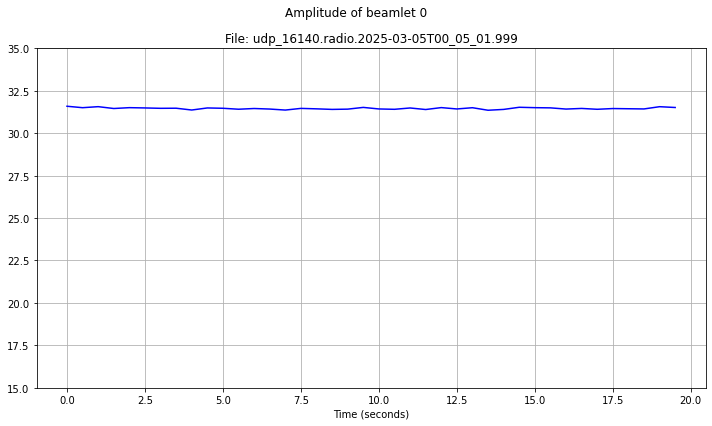

In [37]:
import struct
import numpy as np
import matplotlib.pyplot as plt

#folder = r"C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data"
filename = r"C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data\udp_16140.radio.2025-03-05T00_05_01.999"
#files = sorted([f for f in os.listdir(folder)]) #alphabetically orders files

#change from samples to time
dt = 1024/(200e6) #duration of 1 sample
downsampling_rate = 2 #2 points/second
secs_per_point = 1/downsampling_rate
npacks_halfsec = int(secs_per_point/(dt * 16))

byte_size = os.path.getsize(filename)
npacks_total = byte_size // 7824 #each packet has 7824 bytes

beamlet_num = 0    
#spectra_blocks = []
#times = []
#seq_start = None;
amplitudes = []
read_packs = 0

#READ DATA AND REMOVE '0's
with open(filename, "rb") as f:
    while True:
        packet = f.read(7824)
        if len(packet) < 7824: 
            break # End of file

        # Read as 16-bit integers (combines every 2 bytes into 1 number)
        data = np.frombuffer(packet[16:], dtype=np.int16)

        #DROP 0 PACKETS
        if np.any(data):
            #sequence = struct.unpack('>I', packet[12:16])[0]
            #if seq_start is None: 
            #    seq_start = sequence
            #times.append((sequence - seq_start) * dt)

            beamlets_data = data.reshape((61, 16, 4))
            real = beamlets_data[beamlet_num, :, 0].astype(float)
            imag = beamlets_data[beamlet_num, :, 1].astype(float)

            # TASK: Spectra. Calculate amplitude and do mean of the 16 samples
            # We have an array of 61 values (1 per beamlet)
            #amp_packet = np.mean(np.sqrt(real**2 + imag**2), axis=1)
            #spectra_blocks.append(amp_packet)
            amplitudes.append(np.mean(np.sqrt(real**2 + imag**2)))

            read_packs += 1
            if read_packs % npacks_halfsec == 0:
                secs = (read_packs/npacks_halfsec) * secs_per_point
                print(f"{secs} seconds ({read_packs} packets) of data processed")

#spectra_all = np.array(spectra_blocks)
#times_all = np.array(times)
amplitudes = np.array(amplitudes)
print(f"Valid read packs: {len(amplitudes)} (of total {npacks_total})")
dif = npacks_total - len(amplitudes)
print(f"Seconds with no data: {dif * dt * 16}")
print(npacks_total * dt * 16)

#if len(spectra_all) >= npacks_halfsec:
if len(amplitudes) >= npacks_halfsec:
    #beamlet_max = np.max(spectra_all, axis=0) 
    #beamlet_w_data = np.where(beamlet_max > 0)[0]
    #spectra_clean = spectra_all[:, beamlet_w_data] # only columns with info

    #DOWNSAMPLING
    n_blocks = len(amplitudes) // npacks_halfsec
    amplitudes_plot = amplitudes[:n_blocks * npacks_halfsec]
    #spectra_2hz = np.mean(spectra_plot.reshape(n_blocks, npacks_halfsec, len(beamlet_w_data)), axis=1)
    amplitudes_2hz = np.mean(amplitudes_plot.reshape(-1, npacks_halfsec), axis=1)
    #spectra_plot = spectra_2hz.T

    #times_plot = times_all[:n_blocks * npacks_halfsec]
    #times_2hz = np.mean(times_plot.reshape(n_blocks, npacks_halfsec), axis=1)
    times_2hz = np.arange(len(amplitudes_2hz)) * secs_per_point

    # Spectra Plot all files together + Time in seconds
    plt.figure(figsize=(10, 6))
    # Usamos 'extent' para convertir directamente los píxeles del eje X en Segundos (cada bloque es 0.5s)
    #plt.imshow(spectra_plot, aspect='auto', cmap='viridis', interpolation='none',
    #           origin='lower',extent=[times_2hz[0], times_2hz[-1], beamlet_w_data[-1]+0.5, beamlet_w_data[0]-0.5]) 
    #plt.title("Dynamic Spectra Plot (Downsampled to 2Hz)")
    plt.plot(times_2hz, amplitudes_2hz, color = 'b')
    plt.suptitle(f"Amplitude of beamlet {beamlet_num}")
    plt.title(f"File: {os.path.basename(filename)}")
    plt.xlabel("Time (seconds)")
    plt.ylim(15,35)
    #plt.ylabel("Beamlets (frequency index)")
    #plt.colorbar(label="Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Read full observation

Leyendo archivo: C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data\udp_16140.radio.2025-03-05T00_04_31.001...
0.5 seconds (6103 packets) of data processed
1.0 seconds (12206 packets) of data processed
1.5 seconds (18309 packets) of data processed
2.0 seconds (24412 packets) of data processed
2.5 seconds (30515 packets) of data processed
3.0 seconds (36618 packets) of data processed
3.5 seconds (42721 packets) of data processed
4.0 seconds (48824 packets) of data processed
4.5 seconds (54927 packets) of data processed
5.0 seconds (61030 packets) of data processed
5.5 seconds (67133 packets) of data processed
6.0 seconds (73236 packets) of data processed
6.5 seconds (79339 packets) of data processed
7.0 seconds (85442 packets) of data processed
7.5 seconds (91545 packets) of data processed
8.0 seconds (97648 packets) of data processed
8.5 seconds (103751 packets) of data processed
9.0 seconds (109854 packets) of data processed
9.5 seconds (115957 packets) of

Leyendo archivo: C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data\udp_16140.radio.2025-03-05T00_06_32.000...
80.5 seconds (982583 packets) of data processed
81.0 seconds (988686 packets) of data processed
81.5 seconds (994789 packets) of data processed
82.0 seconds (1000892 packets) of data processed
82.5 seconds (1006995 packets) of data processed
83.0 seconds (1013098 packets) of data processed
83.5 seconds (1019201 packets) of data processed
84.0 seconds (1025304 packets) of data processed
84.5 seconds (1031407 packets) of data processed
85.0 seconds (1037510 packets) of data processed
85.5 seconds (1043613 packets) of data processed
86.0 seconds (1049716 packets) of data processed
86.5 seconds (1055819 packets) of data processed
87.0 seconds (1061922 packets) of data processed
87.5 seconds (1068025 packets) of data processed
88.0 seconds (1074128 packets) of data processed
88.5 seconds (1080231 packets) of data processed
89.0 seconds (1086334 packets)

157.5 seconds (1922445 packets) of data processed
158.0 seconds (1928548 packets) of data processed
158.5 seconds (1934651 packets) of data processed
159.0 seconds (1940754 packets) of data processed
159.5 seconds (1946857 packets) of data processed
160.0 seconds (1952960 packets) of data processed
Leyendo archivo: C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data\udp_16140.radio.2025-03-05T00_08_32.000...
160.5 seconds (1959063 packets) of data processed
161.0 seconds (1965166 packets) of data processed
161.5 seconds (1971269 packets) of data processed
162.0 seconds (1977372 packets) of data processed
162.5 seconds (1983475 packets) of data processed
163.0 seconds (1989578 packets) of data processed
163.5 seconds (1995681 packets) of data processed
164.0 seconds (2001784 packets) of data processed
164.5 seconds (2007887 packets) of data processed
165.0 seconds (2013990 packets) of data processed
165.5 seconds (2020093 packets) of data processed
166.0 seco

234.0 seconds (2856204 packets) of data processed
234.5 seconds (2862307 packets) of data processed
235.0 seconds (2868410 packets) of data processed
235.5 seconds (2874513 packets) of data processed
236.0 seconds (2880616 packets) of data processed
236.5 seconds (2886719 packets) of data processed
237.0 seconds (2892822 packets) of data processed
237.5 seconds (2898925 packets) of data processed
238.0 seconds (2905028 packets) of data processed
238.5 seconds (2911131 packets) of data processed
239.0 seconds (2917234 packets) of data processed
239.5 seconds (2923337 packets) of data processed
240.0 seconds (2929440 packets) of data processed
240.5 seconds (2935543 packets) of data processed
Leyendo archivo: C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data\udp_16140.radio.2025-03-05T00_10_32.000...
241.0 seconds (2941646 packets) of data processed
241.5 seconds (2947749 packets) of data processed
242.0 seconds (2953852 packets) of data processed
242.5 seco

310.5 seconds (3789963 packets) of data processed
311.0 seconds (3796066 packets) of data processed
311.5 seconds (3802169 packets) of data processed
312.0 seconds (3808272 packets) of data processed
312.5 seconds (3814375 packets) of data processed
313.0 seconds (3820478 packets) of data processed
313.5 seconds (3826581 packets) of data processed
314.0 seconds (3832684 packets) of data processed
314.5 seconds (3838787 packets) of data processed
315.0 seconds (3844890 packets) of data processed
315.5 seconds (3850993 packets) of data processed
316.0 seconds (3857096 packets) of data processed
316.5 seconds (3863199 packets) of data processed
317.0 seconds (3869302 packets) of data processed
317.5 seconds (3875405 packets) of data processed
318.0 seconds (3881508 packets) of data processed
318.5 seconds (3887611 packets) of data processed
319.0 seconds (3893714 packets) of data processed
319.5 seconds (3899817 packets) of data processed
320.0 seconds (3905920 packets) of data processed


387.0 seconds (4723722 packets) of data processed
387.5 seconds (4729825 packets) of data processed
388.0 seconds (4735928 packets) of data processed
388.5 seconds (4742031 packets) of data processed
389.0 seconds (4748134 packets) of data processed
389.5 seconds (4754237 packets) of data processed
390.0 seconds (4760340 packets) of data processed
390.5 seconds (4766443 packets) of data processed
391.0 seconds (4772546 packets) of data processed
391.5 seconds (4778649 packets) of data processed
392.0 seconds (4784752 packets) of data processed
392.5 seconds (4790855 packets) of data processed
393.0 seconds (4796958 packets) of data processed
393.5 seconds (4803061 packets) of data processed
394.0 seconds (4809164 packets) of data processed
394.5 seconds (4815267 packets) of data processed
395.0 seconds (4821370 packets) of data processed
395.5 seconds (4827473 packets) of data processed
396.0 seconds (4833576 packets) of data processed
396.5 seconds (4839679 packets) of data processed


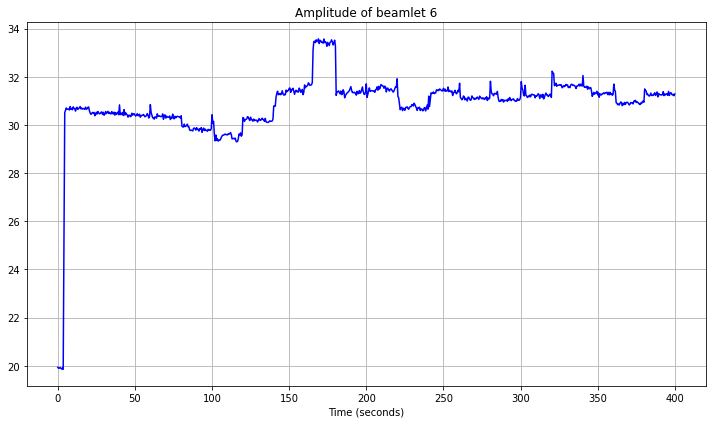

In [25]:
import struct
import numpy as np
import matplotlib.pyplot as plt

folder = r"C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data"
#filename = r"C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data\udp_16140.radio.2025-03-05T00_04_31.001"
files = sorted([f for f in os.listdir(folder)]) #alphabetically orders files

#change from samples to time
dt = 1024/(200e6) #duration of 1 sample
downsampling_rate = 2 #2 points/second
secs_per_point = 1/downsampling_rate
npacks_halfsec = int(secs_per_point/(dt * 16))

beamlet_num = 6    
#spectra_blocks = []
#times = []
#seq_start = None;
amplitudes = []
read_packs = 0

#READ DATA AND REMOVE '0's
for file in files:
    filename = os.path.join(folder, file)
    print(f"Reading file: {filename}...")
    with open(filename, "rb") as f:
        while True:
            packet = f.read(7824)
            if len(packet) < 7824: 
                break # End of file

            # Read as 16-bit integers (combines every 2 bytes into 1 number)
            data = np.frombuffer(packet[16:], dtype=np.int16)

            #DROP 0 PACKETS
            if np.any(data):
                #sequence = struct.unpack('>I', packet[12:16])[0]
                #if seq_start is None: 
                #    seq_start = sequence
                #times.append((sequence - seq_start) * dt)

                beamlets_data = data.reshape((61, 16, 4))
                real = beamlets_data[beamlet_num, :, 0].astype(float)
                imag = beamlets_data[beamlet_num, :, 1].astype(float)

                # TASK: Spectra. Calculate amplitude and do mean of the 16 samples
                # We have an array of 61 values (1 per beamlet)
                #amp_packet = np.mean(np.sqrt(real**2 + imag**2), axis=1)
                #spectra_blocks.append(amp_packet)
                amplitudes.append(np.mean(np.sqrt(real**2 + imag**2)))

                read_packs += 1
                if read_packs % npacks_halfsec == 0:
                    secs = (read_packs/npacks_halfsec) * secs_per_point
                    #print(f"{secs} seconds ({read_packs} packets) of data processed")

#spectra_all = np.array(spectra_blocks)
#times_all = np.array(times)
amplitudes = np.array(amplitudes)
print(f"Valid read packs: {len(amplitudes)}")

#if len(spectra_all) >= npacks_halfsec:
if len(amplitudes) >= npacks_halfsec:
    #beamlet_max = np.max(spectra_all, axis=0) 
    #beamlet_w_data = np.where(beamlet_max > 0)[0]
    #spectra_clean = spectra_all[:, beamlet_w_data] # only columns with info

    #DOWNSAMPLING
    n_blocks = len(amplitudes) // npacks_halfsec
    amplitudes_plot = amplitudes[:n_blocks * npacks_halfsec]
    #spectra_2hz = np.mean(spectra_plot.reshape(n_blocks, npacks_halfsec, len(beamlet_w_data)), axis=1)
    amplitudes_2hz = np.mean(amplitudes_plot.reshape(-1, npacks_halfsec), axis=1)
    #spectra_plot = spectra_2hz.T

    #times_plot = times_all[:n_blocks * npacks_halfsec]
    #times_2hz = np.mean(times_plot.reshape(n_blocks, npacks_halfsec), axis=1)
    times_2hz = np.arange(len(amplitudes_2hz)) * secs_per_point

    # Spectra Plot all files together + Time in seconds
    plt.figure(figsize=(10, 6))
    # Usamos 'extent' para convertir directamente los píxeles del eje X en Segundos (cada bloque es 0.5s)
    #plt.imshow(spectra_plot, aspect='auto', cmap='viridis', interpolation='none',
    #           origin='lower',extent=[times_2hz[0], times_2hz[-1], beamlet_w_data[-1]+0.5, beamlet_w_data[0]-0.5]) 
    #plt.title("Dynamic Spectra Plot (Downsampled to 2Hz)")
    plt.plot(times_2hz, amplitudes_2hz, color = 'b')
    plt.title(f"Amplitude of beamlet {beamlet_num}")
    plt.xlabel("Time (seconds)")
    #plt.ylabel("Beamlets (frequency index)")
    #plt.colorbar(label="Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Leyendo: udp_16140.radio.2025-03-05T00_04_31.001...
Leyendo: udp_16140.radio.2025-03-05T00_05_01.999...
Leyendo: udp_16140.radio.2025-03-05T00_05_31.999...
Leyendo: udp_16140.radio.2025-03-05T00_06_02.000...
Leyendo: udp_16140.radio.2025-03-05T00_06_32.000...
Leyendo: udp_16140.radio.2025-03-05T00_07_01.999...
Leyendo: udp_16140.radio.2025-03-05T00_07_31.999...
Leyendo: udp_16140.radio.2025-03-05T00_08_02.000...
Leyendo: udp_16140.radio.2025-03-05T00_08_32.000...
Leyendo: udp_16140.radio.2025-03-05T00_09_01.999...
Leyendo: udp_16140.radio.2025-03-05T00_09_31.999...
Leyendo: udp_16140.radio.2025-03-05T00_10_02.000...
Leyendo: udp_16140.radio.2025-03-05T00_10_32.000...
Leyendo: udp_16140.radio.2025-03-05T00_11_01.999...
Leyendo: udp_16140.radio.2025-03-05T00_11_31.999...
Leyendo: udp_16140.radio.2025-03-05T00_12_02.000...
Leyendo: udp_16140.radio.2025-03-05T00_12_32.000...
Leyendo: udp_16140.radio.2025-03-05T00_13_01.999...
Leyendo: udp_16140.radio.2025-03-05T00_13_31.999...
Leyendo: udp

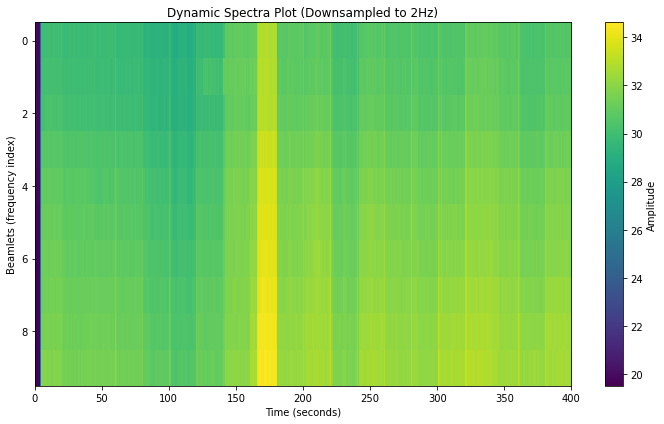

In [40]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt

folder = r"C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data"
# Solo lee archivos udp
files = sorted([f for f in os.listdir(folder) if "udp" in f]) 

dt = 1024/(200e6) 
downsampling_rate = 2 
secs_per_point = 1/downsampling_rate
npacks_halfsec = int(secs_per_point/(dt * 16))
    
spectra_blocks = []
read_packs = 0

for file in files:
    filename = os.path.join(folder, file)
    print(f"Reading {file}...")
    with open(filename, "rb") as f:
        while True:
            packet = f.read(7824)
            if len(packet) < 7824: 
                break

            data = np.frombuffer(packet[16:], dtype=np.int16)

            if np.any(data):
                beamlets_data = data.reshape((61, 16, 4))
                # Lee TODOS los beamlets (matriz 2D)
                real = beamlets_data[:, :, 0].astype(float)
                imag = beamlets_data[:, :, 1].astype(float)

                amp_packet = np.mean(np.sqrt(real**2 + imag**2), axis=1)
                spectra_blocks.append(amp_packet)

                read_packs += 1

spectra_all = np.array(spectra_blocks)
print(f"Valid read packets: {len(spectra_all)}")

if len(spectra_all) >= npacks_halfsec:
    # Limpiar
    beamlet_max = np.max(spectra_all, axis=0) 
    beamlet_w_data = np.where(beamlet_max > 0)[0]
    spectra_clean = spectra_all[:, beamlet_w_data] 

    # Downsampling
    n_blocks = len(spectra_clean) // npacks_halfsec
    spectra_recortado = spectra_clean[:n_blocks * npacks_halfsec]
    
    spectra_2hz = np.mean(spectra_recortado.reshape(n_blocks, npacks_halfsec, len(beamlet_w_data)), axis=1)
    spectra_plot = spectra_2hz.T

    # Tiempo
    times_2hz = np.arange(n_blocks) * secs_per_point

    # Dibujar
    plt.figure(figsize=(10, 6))
    plt.imshow(spectra_plot, aspect='auto', cmap='viridis', interpolation='none',
               origin='lower', extent=[times_2hz[0], times_2hz[-1], beamlet_w_data[-1]+0.5, beamlet_w_data[0]-0.5]) 
    plt.title("Dynamic Spectra Plot (Downsampled)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Beamlets (frequency index)")
    plt.colorbar(label="Amplitude")
    plt.tight_layout()
    plt.show()

import zstandard as zstd
import os

folder = r"C:\Users\loren\OneDrive - UPNA\Escritorio\UNI\TFG\THESIS CODES\observation_data"
dctx = zstd.ZstdDecompressor()

#### Leer y ordenar los archivos de la carpeta
for file in sorted(os.listdir(folder)):
    if file.endswith(".zst"):
        path_compressed = os.path.join(folder, file)
        path_uncompressed = path_compressed[:-4] # Quita el ".zst" del nombre final

        # Descomprimir
        with open(path_compressed, 'rb') as comp, open(path_uncompressed, 'wb') as uncomp:
            dctx.copy_stream(comp, uncomp)
            
        print(f"Descomprimido: {file}")

print("¡Todo listo!")